In [24]:
import sys
sys.path.insert(1, '..')

import os, yaml, pickle

from physics.simulation import msq, sample as s
from physics.hzz import zpair, zz4l
from physics.hstar import c6
from datasets import coefficient
from models import rolypoly

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import hist
import pandas as pd

import torch
from lightning import Trainer

In [25]:
OUTPUT_DIR = '../jobs/rolypoly/refactor-one'
SCALER_FILE = 'scaler.pkl'
CHECKPOINT_DIR = 'checkpoints'
SAMPLE_DIR = '../..'

checkpoint_epoch = 199
checkpoint_loss = '0.00'

CHECKPOINT = f'checkpoint-rolypoly-epoch={checkpoint_epoch}-val_loss={checkpoint_loss}.ckpt'

VERSION_NO = 0
LIGHTNING_DIR = f'lightning_logs/version_{VERSION_NO}'

COMPONENT = msq.Component.SBI

FEATURES = ['mandelstam_s', 'mandelstam_t', 'mandelstam_u']
COEFFICIENT_INDEX = 1
SAMPLE_SIZE = 50000
BATCH_SIZE = 64
SEED = 42

In [26]:
with open(os.path.join(OUTPUT_DIR, LIGHTNING_DIR, 'hparams.yaml'), 'r') as f:
    params = yaml.load(f, Loader=yaml.CLoader)

In [27]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

component_names = {
    msq.Component.SBI : 'SBI',
    msq.Component.SIG : 'SIG',
    msq.Component.INT : 'INT',
    msq.Component.BKG : 'BKG'
}

In [28]:
sample = s.from_csv(cross_section=1.0, file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT]), n_rows=100000)
        
z_cand = zpair.ZPairCandidate(algorithm='truth')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
mandelstam = zz4l.MandelstamVariables()

sample = sample.calculate(z_cand).filter(z_masses).calculate(mandelstam)

0.5379746106337265


In [29]:
c6_mod = c6.Modifier(baseline=COMPONENT, sample=sample, c6_values=[-5,-1,0,1,5]) if COMPONENT!=msq.Component.INT else c6.Modifier(baseline=COMPONENT, sample=sample, c6_values=[-5,0,5])
coefficient = c6_mod.coefficients[:,COEFFICIENT_INDEX]

unweighted_indices = sample.weights.sample(n=SAMPLE_SIZE, replace=True, weights=sample.weights, random_state=SEED).index
        
X = sample.kinematics[FEATURES].to_numpy()[unweighted_indices]

with open(os.path.join(OUTPUT_DIR, SCALER_FILE), 'rb') as f:
    scaler = pickle.load(f)

X = torch.tensor(scaler.transform(X), dtype=torch.float32).cpu()
y = coefficient[unweighted_indices]

In [30]:
print(X)

tensor([[-0.6345, -0.5260, -0.4836],
        [-0.5853, -0.4505, -0.4533],
        [-0.4809, -0.5513, -0.1897],
        ...,
        [-0.6025, -0.5602, -0.3826],
        [-0.4701, -0.5722, -0.2208],
        [-0.5746, -0.2788, -0.6573]])


In [31]:
loaded_model = rolypoly.ROLYPOLY.load_from_checkpoint(os.path.join(OUTPUT_DIR, CHECKPOINT_DIR, CHECKPOINT), map_location=torch.device('cpu'), learning_rate=params['learning_rate'], n_features=params['n_features'], n_layers=params['n_layers'], n_nodes=params['n_nodes'])

In [32]:
predictions = loaded_model(X).detach().view(-1).numpy()

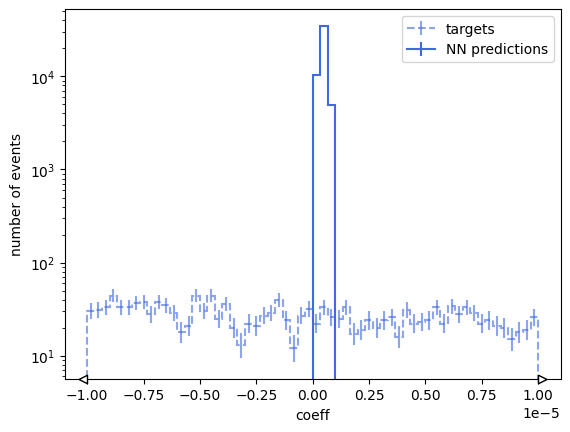

In [ ]:
BINS = 60

bounds = [-1.2e-2,5e-3]
bounds = [-1e-6,1e-6]

h_predictions_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_predictions_train.fill(predictions)

h_targets_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_targets_train.fill(y)

h_targets_train.plot(color='royalblue', linestyle='--', label='targets', alpha=0.6)
h_predictions_train.plot(color='royalblue', linestyle='-', label='NN predictions')

plt.xlabel(f'coeff')
plt.ylabel('number of events')
plt.yscale('log')

plt.legend()

plt.show()

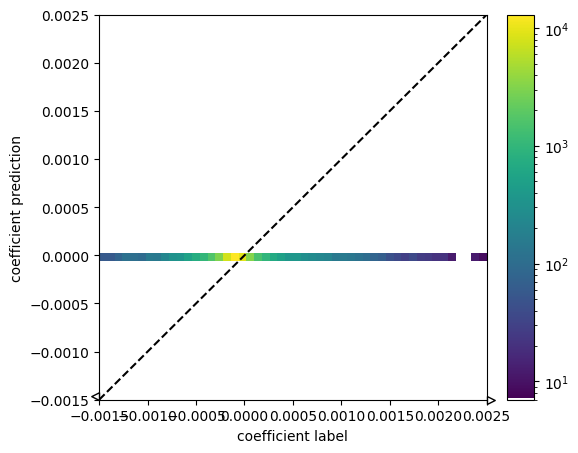

In [50]:
BINS=50

bounds = [-1.5e-3,2.5e-3]
#bounds = [-1e-5,1e-5]

h_calibration_train = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name='coefficient label'),
    hist.axis.Regular(BINS, *bounds, name='coefficient prediction')
)

h_calibration_train.fill(y, predictions)

cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

fig = plt.figure(figsize=(5,5))

h_calibration_train.plot2d(cmap=cmap, cbar=True, norm=LogNorm())
plt.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')


plt.show()

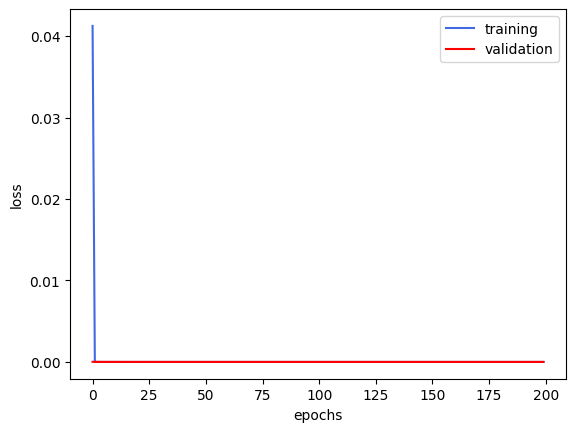

In [48]:
metrics = pd.read_csv(os.path.join(OUTPUT_DIR, LIGHTNING_DIR, 'metrics.csv'))

epochs = np.unique(metrics['epoch'].to_numpy())
train_loss = metrics['train_loss'].dropna().to_numpy()
val_loss = metrics['val_loss'].dropna().to_numpy()

plt.plot(epochs, train_loss, color='royalblue', label='training')
plt.plot(epochs, val_loss, color='red', label='validation')

plt.xlabel('epochs')
plt.ylabel('loss')
#plt.yscale('log')
plt.legend()
plt.show()